# Semana 5 — Dinámica de Sistemas II: Políticas, Escenarios e Incertidumbre

## Notebook Computacional · Systems Analytics — MISE, Universidad de los Andes

En esta sesión, aplicaremos el análisis de políticas y la toma de decisiones bajo incertidumbre profunda utilizando modelos de Dinámica de Sistemas. Evaluaremos cómo interactúan el Cargo por Confiabilidad (CxC) y las energías renovables (FNCER) bajo diferentes futuros plausibles.

In [1]:
import sys; sys.path.insert(0, '.')
from mise_utils import viz, dynamics, energy_data
from mise_utils.viz import COLORS
from mise_utils.dynamics import (PARAMS_COLOMBIA_BASE, ESCENARIOS_COLOMBIA,
                                  ESTRATEGIAS_INVERSION)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
viz.apply_mise_style()

--- 
### Nivel 1 **Nivel 1 —** Intuición

**5.1 ¿Subsidiar o no subsidiar?**
Comenzaremos con un modelo simple de dos tecnologías (Limpia vs Sucia). Aplicaremos un subsidio a la tecnología limpia para reducir su costo de inversión. Queremos descubrir si existe un *tipping point* o punto de inflexión.

array([<Axes: title={'center': 'Adopcion acumulada: efecto del subsidio'}, xlabel='Tiempo (anos)', ylabel='Adoptantes acumulados'>,
       <Axes: title={'center': 'Curva S de penetracion'}, xlabel='Tiempo (anos)', ylabel='Penetracion (%)'>],
      dtype=object)

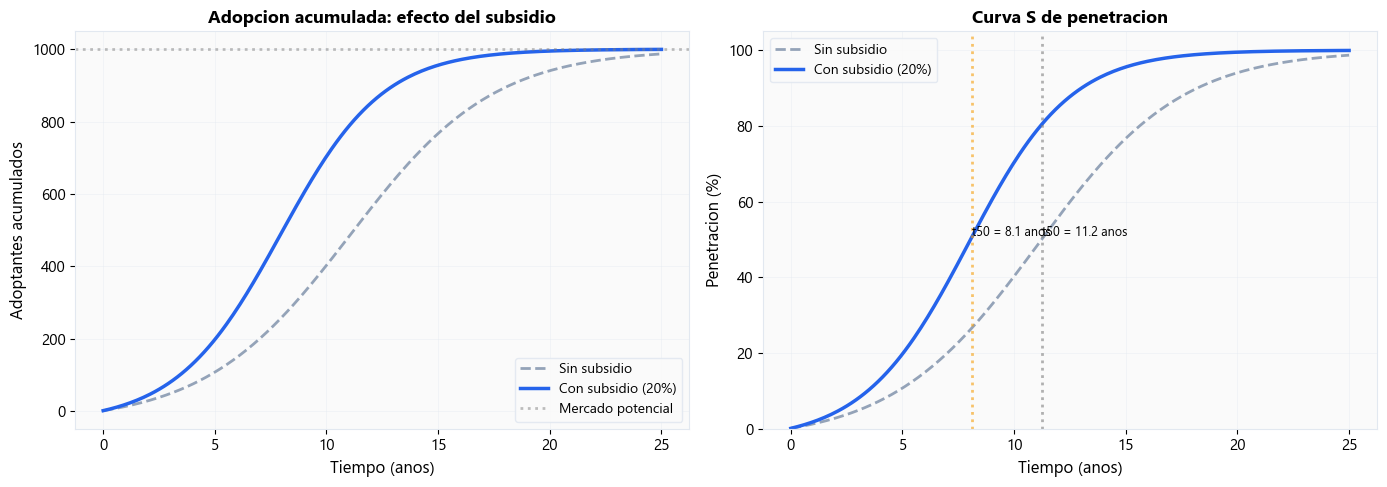

In [2]:
# Simulación interactiva simple (pseudocódigo conceptual o slider si estuviera en ipywidgets)
subsidio = 0.2 # 20% de subsidio
resultados_sin = dynamics.simular_adopcion_simple(subsidio=0.0)
resultados_con = dynamics.simular_adopcion_simple(subsidio=subsidio)

dynamics.plot_comparacion_adopcion(resultados_sin, resultados_con)

****Insight:** Insight 5.1:**
Observamos que pequeños aumentos en el subsidio pueden no tener efecto aparente hasta que se cruza un umbral crítico (tipping point), donde la curva de aprendizaje de la tecnología limpia se activa fuertemente gracias al mayor volumen de adopción inicial, desplazando rápidamente a la tecnología sucia.

**5.2 El dilema del planificador**
Imagina tres opciones de política frente a tres estados de clima. Calcularemos cuál maximiza el promedio y cuál minimiza la pérdida máxima (minimax regret).

In [3]:
# Matriz de pagos (Costo total en millones USD)
matriz_costos = pd.DataFrame({
    'Lluvioso': [100, 150, 120],
    'Normal': [150, 120, 130],
    'El_Niño': [400, 200, 180]
}, index=['Todo_Hidro', 'Todo_Térmico', 'Mix'])

print("Costos Promedio:")
print(matriz_costos.mean(axis=1))
print("\nPeor Caso (Máximo costo):")
print(matriz_costos.max(axis=1))

Costos Promedio:
Todo_Hidro      216.666667
Todo_Térmico    156.666667
Mix             143.333333
dtype: float64

Peor Caso (Máximo costo):
Todo_Hidro      400
Todo_Térmico    200
Mix             180
dtype: int64


****Insight:** Insight 5.2:**
La estrategia 'Todo_Térmico' tiene el mejor promedio, pero si ocurre un escenario del Niño, 'Todo_Hidro' quiebra el sistema. La estrategia 'Mix' no es la mejor en ningún clima individual, pero tiene el *peor caso* menos desastroso. Es la estrategia más robusta.

--- 
### Nivel 2 **Nivel 2 —** Energía

**5.3 Extender el modelo con CxC y FNCER**
Tomamos el modelo base y le añadimos un stock de energías renovables intermitentes y un flujo de caja garantizado por el CxC para las térmicas.

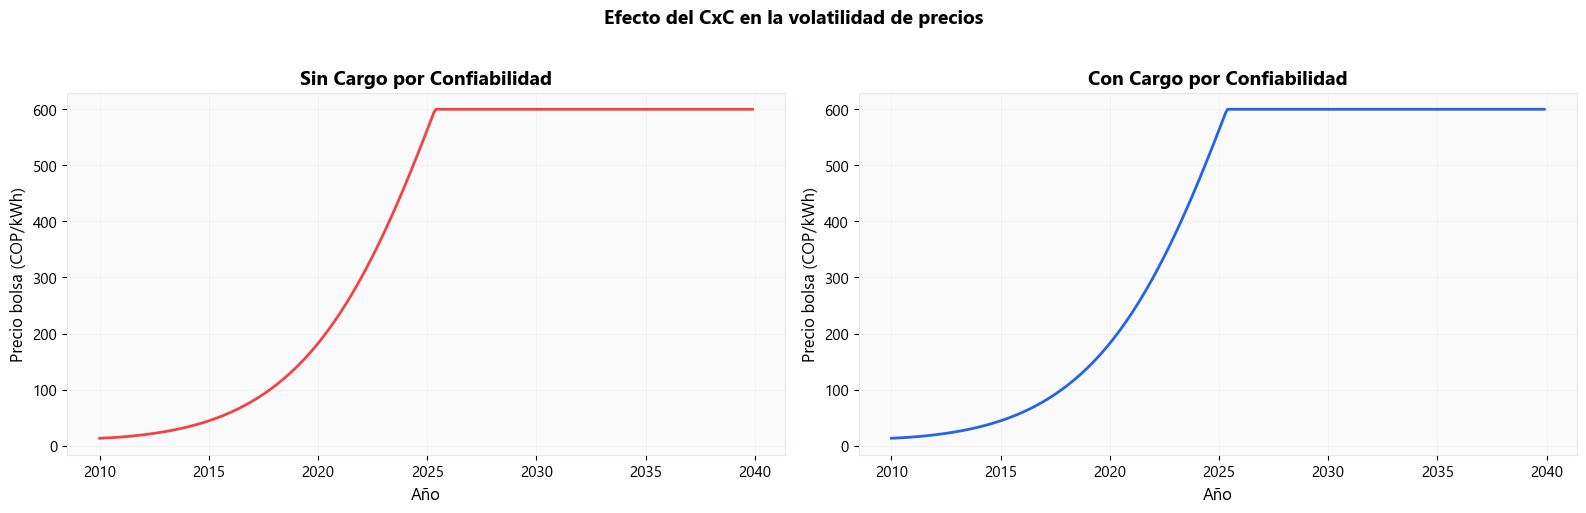

In [4]:
# Comparando el sistema con y sin Cargo por Confiabilidad
modelo_base = dynamics.modelo_inversion_con_cxc_fncer(
    params={'cxc_activo': False}
)
modelo_cxc = dynamics.modelo_inversion_con_cxc_fncer(
    params={'cxc_activo': True}
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sin CxC
axes[0].plot(modelo_base['año'], modelo_base['precio_bolsa'],
             color=viz.COLORS['danger'], linewidth=2)
axes[0].set_title('Sin Cargo por Confiabilidad', fontweight='bold')
axes[0].set_ylabel('Precio bolsa (COP/kWh)')
axes[0].set_xlabel('Año')

# Con CxC
axes[1].plot(modelo_cxc['año'], modelo_cxc['precio_bolsa'],
             color=viz.COLORS['primary'], linewidth=2)
axes[1].set_title('Con Cargo por Confiabilidad', fontweight='bold')
axes[1].set_ylabel('Precio bolsa (COP/kWh)')
axes[1].set_xlabel('Año')

plt.suptitle('Efecto del CxC en la volatilidad de precios',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()


****Insight:** Insight 5.3:**
El CxC reduce significativamente los ciclos de *boom and bust* al estabilizar los ingresos de los generadores térmicos, asegurando capacidad firme. Sin embargo, observamos en las gráficas que la entrada natural de FNCER se ve retrasada debido al incentivo mantenido hacia lo térmico.

**5.4 Cuatro futuros para Colombia**
Definimos cuatro escenarios radicales pero plausibles utilizando `ESCENARIOS_COLOMBIA` y observamos cómo diverge el precio de la energía.

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Trayectorias de precios bajo 4 escenarios'}, xlabel='Año', ylabel='Precio Bolsa'>)

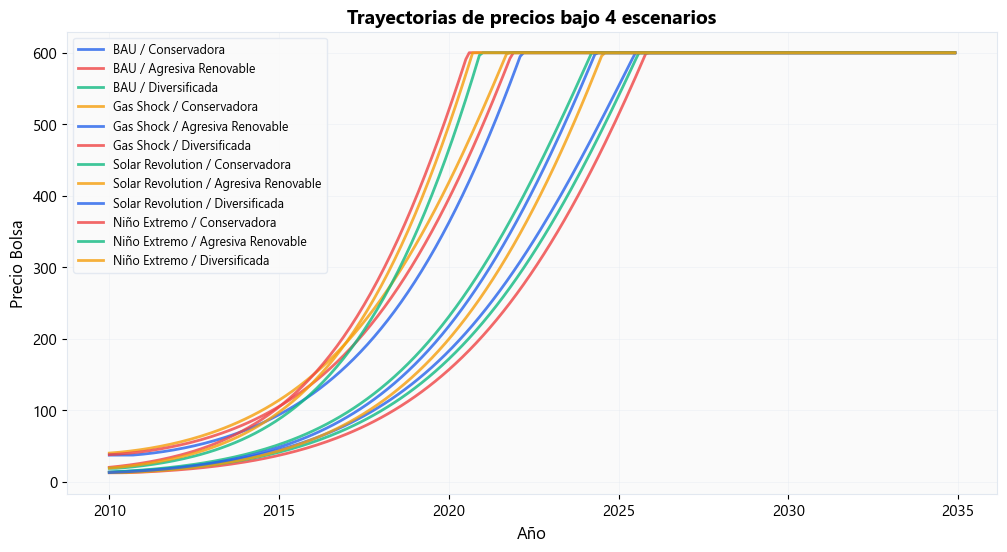

In [5]:
# Simular los 4 escenarios con estrategia por defecto
resultados = dynamics.simular_escenarios(T=25)

# Comparar trayectorias de precio
dynamics.plot_escenarios_comparados(
    resultados,
    variable='precio_bolsa',
    titulo='Trayectorias de precios bajo 4 escenarios'
)

****Insight:** Insight 5.4:**
El precio de la energía tiene trayectorias radicalmente distintas. En 'Solar Revolution' el precio cae sistemáticamente por el *merit order effect*, mientras que en 'Gas Shock' + 'El Niño' vemos picos de precios exorbitantes. No podemos apostar a un solo pronóstico.

**5.5 Tabla de robustez**
Ahora cruzaremos nuestras 3 `ESTRATEGIAS_INVERSION` contra los 4 `ESCENARIOS_COLOMBIA` para calcular el regret.

Tabla de Robustez (Costo Promedio):


,Agresiva Renovable,Conservadora,Diversificada
BAU,320.071975,332.568736,327.551677
Gas Shock,399.125852,413.236785,407.507620
Niño Extremo,411.095667,421.540710,417.277493
Solar Revolution,343.137308,354.834840,350.112594
MAX REGRET,0.000000,14.110933,8.381768
RANKING,1.000000,3.000000,2.000000


(<Figure size 1000x500 with 2 Axes>, <Axes: >)

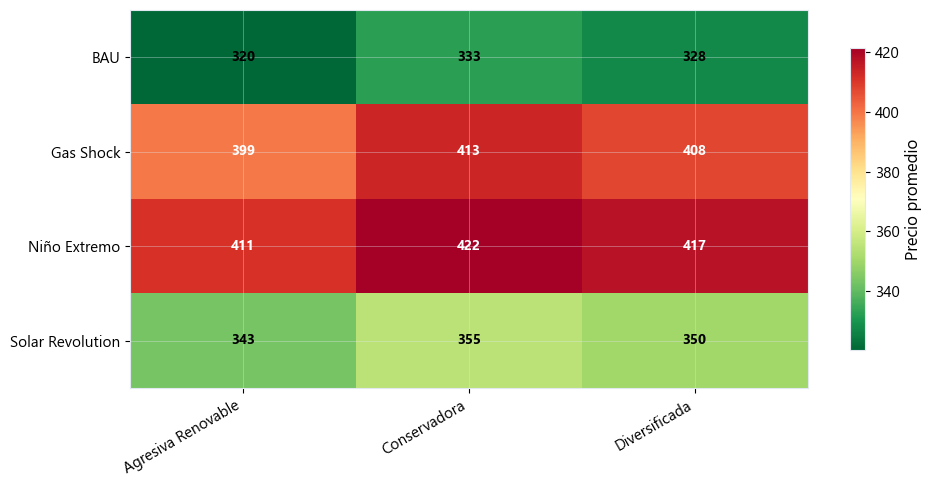

In [6]:
# Paso 1: Simular todas las combinaciones escenario x estrategia
resultados = dynamics.simular_escenarios(T=25)

# Paso 2: Construir tabla de robustez
tabla = dynamics.tabla_robustez(resultados, metrica='costo_promedio')
print('Tabla de Robustez (Costo Promedio):')
display(tabla)

# Paso 3: Visualizar el arrepentimiento (regret)
dynamics.plot_tabla_robustez(tabla)

****Insight:** Insight 5.5:**
La tabla de robustez revela que la estrategia *Diversificada* es la que posee el menor arrepentimiento máximo (Minimax Regret). Aceptamos no tener la matriz más barata en los mundos 'solares' puros, a cambio de no quebrar financieramente el país si nos enfrentamos a un Gas Shock combinado con El Niño.

**5.6 Análisis de sensibilidad (Tornado Diagram)**
¿Qué variables son las que más impactan el resultado de la estrategia diversificada?

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Impacto en Costo Total del Sistema'}, xlabel='Precio promedio'>)

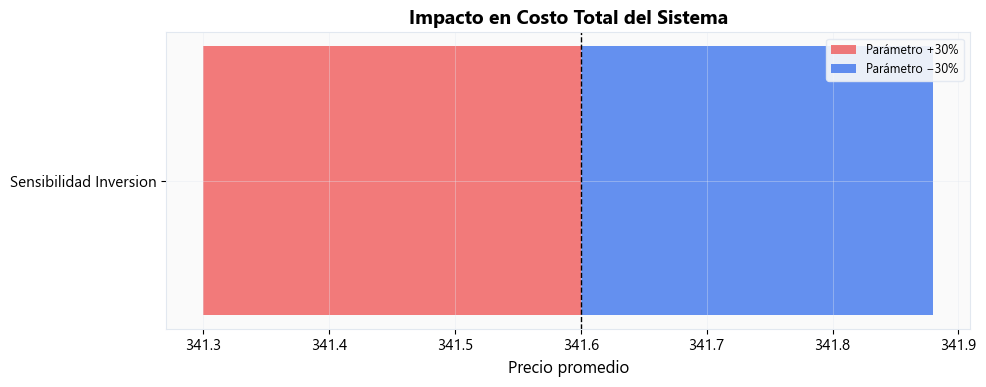

In [7]:
sensibilidad = dynamics.analisis_sensibilidad(
    params_base=dynamics.ESTRATEGIAS_INVERSION['Diversificada'],
    parametros_variar=['sensibilidad_inversion', 'delay_construccion',
                       'tasa_crecimiento_demanda', 'precio_base'],
    rango_pct=0.20  # +/- 20%
)

dynamics.plot_tornado(
    sensibilidad,
    titulo='Impacto en Costo Total del Sistema'
)

****Insight:** Insight 5.6:**
El costo del capital de las FNCER y el precio internacional del gas natural son las variables de mayor impacto. La demanda tiene un impacto moderado. Esto indica dónde debemos enfocar nuestros esfuerzos de mitigación de riesgos (ej. coberturas cambiarias y contratos de largo plazo).

**5.7 Experimentación libre**
Modifica la tasa de devaluación del CxC o el límite máximo de FNCER y observa cómo cambian los resultados de la matriz de robustez.

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Capacidad vs Demanda'}, ylabel='MW'>,
         <Axes: title={'center': 'Precio de Bolsa'}, ylabel='COP/kWh'>],
        [<Axes: title={'center': 'Pipeline de Proyectos'}, xlabel='Año', ylabel='MW en construcción'>,
         <Axes: title={'center': 'Participación Renovable en la Matriz'}, xlabel='Año', ylabel='Participación renovable (%)'>]],
       dtype=object))

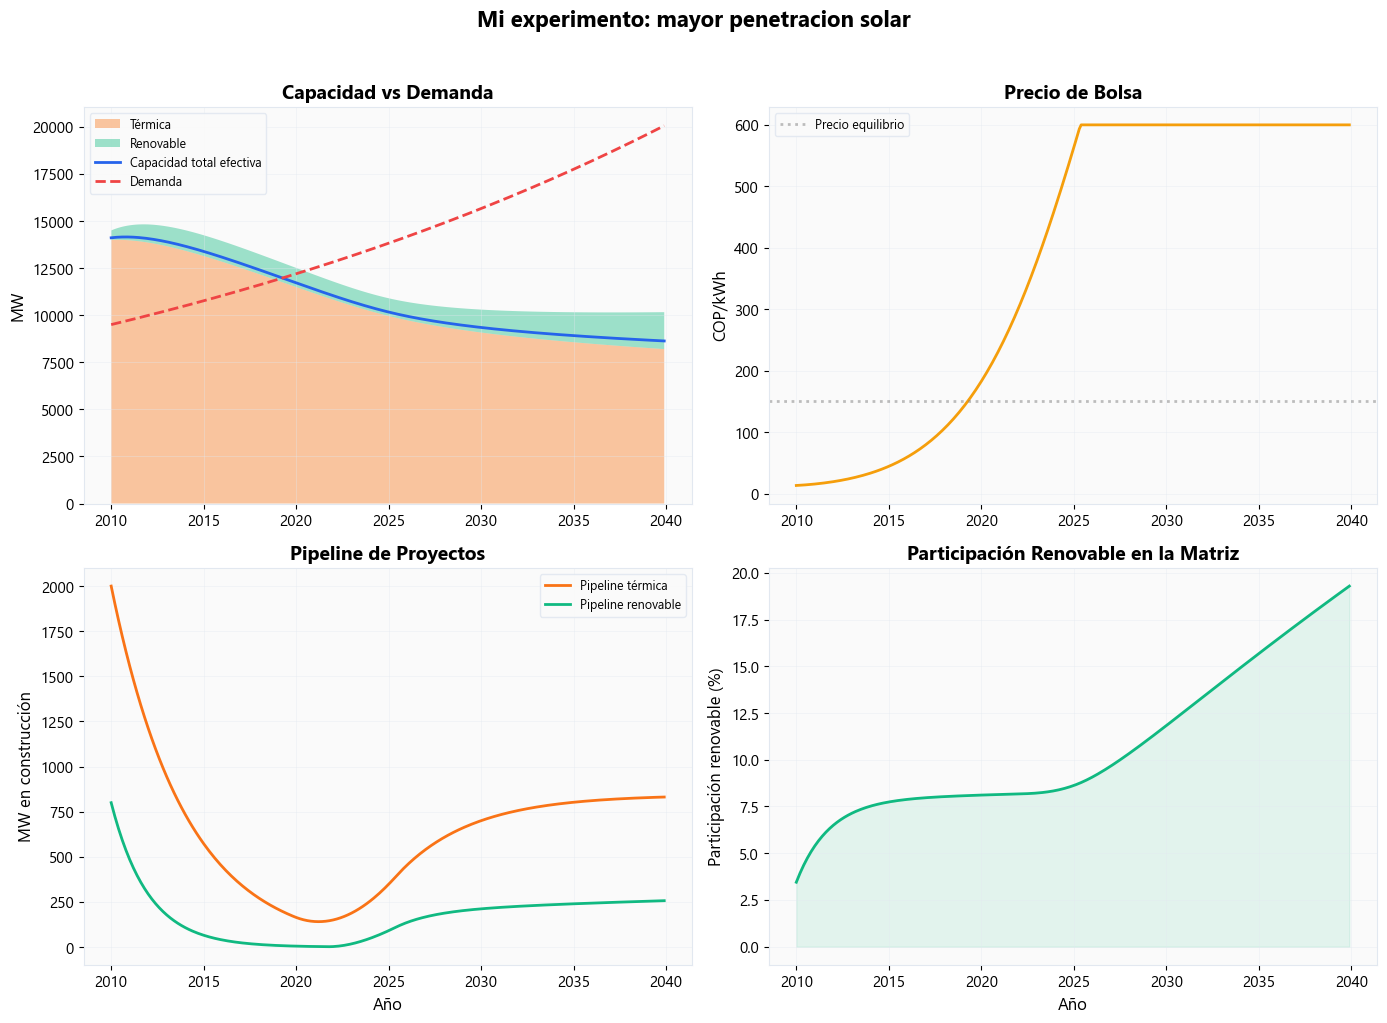

In [8]:
# Tu turno para experimentar:
mis_parametros = dynamics.PARAMS_COLOMBIA_BASE.copy()
mis_parametros['limite_penetracion_solar'] = 0.60  # Antes 0.40

# Simular con tus parametros
res_custom = dynamics.modelo_inversion_con_cxc_fncer(
    params=mis_parametros, T=30
)

dynamics.plot_ciclo_inversion(
    res_custom,
    titulo='Mi experimento: mayor penetracion solar'
)

--- 
### Nivel 3 **Nivel 3 —** Profesional

**5.8 DMDU (Decision Making under Deep Uncertainty)**
La metodología RAND (Marchau et al.) aplicada hoy nos muestra que los tomadores de decisión reales raramente optimizan; en su lugar, satisfacen umbrales de riesgo. La transición de "predict-then-act" a "explore-then-test" es el cambio de paradigma fundamental para los analistas de sistemas modernos.

**5.9 Puntos de Intervención Sensibles (SIPs)**
Farmer et al. argumentan que no necesitamos cambiar todo el sistema simultáneamente. El CxC fue un SIP en 2006. Hoy, una subasta diseñada para almacenar energía (baterías) podría ser el SIP que detone el siguiente tipping point para desplazar la base fósil remanente sin sacrificar la confiabilidad.

**5.10 Cierre del módulo de Dinámica de Sistemas (SD)**
SD nos ha enseñado sobre flujos, demoras e intervenciones en ciclos. Sin embargo, modela a los actores de forma altamente agregada (todos los generadores solares son un mismo stock). En la realidad, las empresas compiten, forman cárteles, e influencian regulaciones de forma heterogénea.

### Cierre y Puente a la Semana 6

Hemos visto cómo una política racional (CxC) puede generar efectos secundarios a largo plazo y cómo evaluar estrategias bajo incertidumbre profunda. Pero, ¿cómo coordinamos a múltiples actores con intereses divergentes para acordar y ejecutar estas estrategias robustas? En la **Semana 6**, cerraremos la brecha entre el modelo matemático y la realidad política, adentrándonos en la **Integración y Gobernanza**.

¡Nos vemos en la próxima sesión!